# Fundamentos de Aprendizagem Automática 2025/2026

## Cátia Pesquita + Diogo F. Soares + Helena Aidos + Joana C. Santos, 2025/2026

# Practical 09 - Explainability


## 0. Introduction

In many real-world applications of machine learning, it is not enough to obtain accurate predictions. We also need to **understand why** a model made a particular decision. This is the goal of **model explainability**.

This practical focuses on three complementary approaches to explaining model predictions:

1. **Decision Tree rules** — a model that is *inherently interpretable*, where we can trace the exact path from input to prediction.
2. **LIME** (Local Interpretable Model-agnostic Explanations) — a *model-agnostic* method that explains individual predictions by fitting a local surrogate model.
3. **SHAP** (SHapley Additive exPlanations) — a *game-theoretic* method that attributes a contribution value to each feature for a given prediction.

By the end of this practical, you should be able to:
- train Decision Tree and Random Forest classifiers and extract their decision rules;
- generate **local** explanations using LIME and SHAP for individual instances;
- generate **global** feature importance from all three approaches;
- compare the explanations and discuss when and why they might disagree;
- understand that "interpretable" does not always mean "easy to understand".

> Main remark: **no single explanation method is perfect**. Each provides a different perspective on the model's behaviour.

**References:**
- Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). "Why Should I Trust You?": Explaining the Predictions of Any Classifier. *KDD 2016*. https://arxiv.org/abs/1602.04938

In [1]:
# --- Core libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Scikit-learn ---
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from collections import defaultdict

# --- Explainability libraries ---
from lime.lime_tabular import LimeTabularExplainer
import shap

shap.initjs()

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = list(iris.feature_names)
class_names = list(iris.target_names)

# Train/test split (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Classes: {class_names}")
print(f"Features: {feature_names}")
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"\nClass distribution in train set:")
print(pd.Series(y_train).value_counts().sort_index().to_string())

Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Train: 105 | Test: 45

Class distribution in train set:
0    31
1    37
2    37


## 1. Interpretable and black-box models

In [3]:
# --- Shallow Decision Tree (interpretable) ---
dt_shallow = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_shallow.fit(X_train, y_train)

# --- Full Decision Tree (unconstrained, may overfit) ---
dt_full = DecisionTreeClassifier(random_state=42)
dt_full.fit(X_train, y_train)

# --- Random Forest (black-box baseline) ---
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Print accuracy, number of leaves and depth for each model
for name, model in [("DT shallow (d=3)", dt_shallow),
                    ("DT full (unlimited)", dt_full)]:
    acc = accuracy_score(y_test, model.predict(X_test))
    leaves = model.get_n_leaves()
    depth = model.get_depth()
    print(f"{name:25s} | Accuracy: {acc:.3f} | Leaves: {leaves:3d} | Depth: {depth}")

DT shallow (d=3)          | Accuracy: 1.000 | Leaves:   5 | Depth: 3
DT full (unlimited)       | Accuracy: 1.000 | Leaves:  10 | Depth: 6


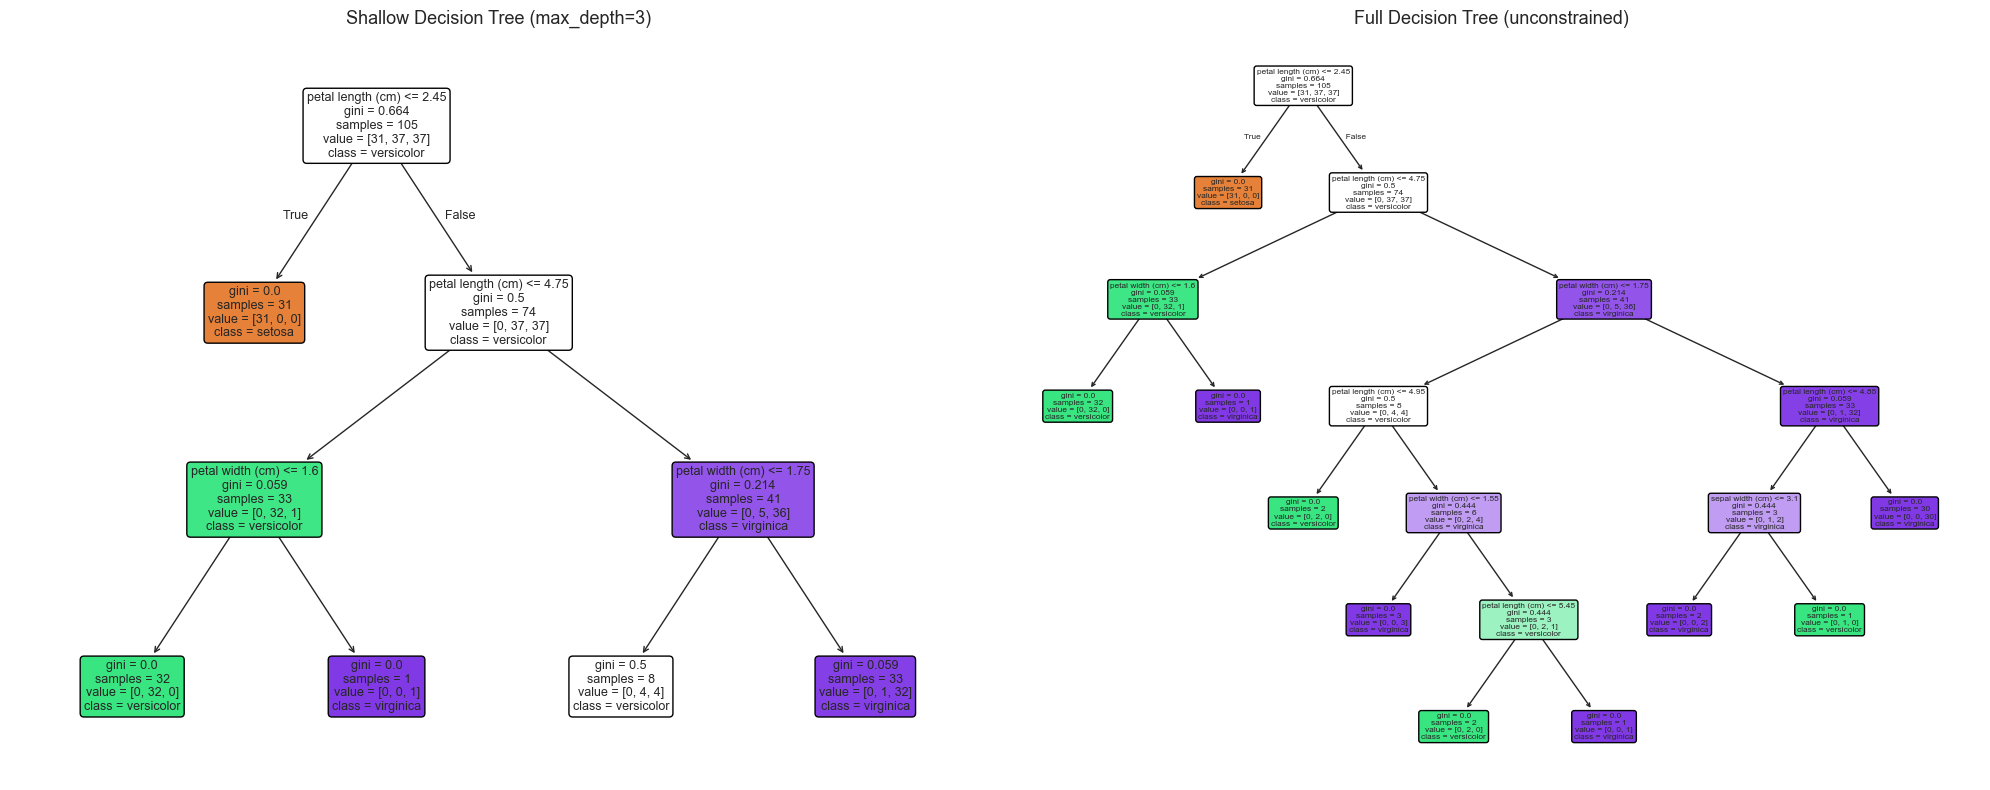


The shallow tree has 5 leaves.
The full tree has 10 leaves!
Even depth=3 produces several branches. 'Interpretable' does not mean 'simple'!


In [4]:
# Plot both trees side by side for visual comparison
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

plot_tree(dt_shallow,
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          ax=axes[0],
          fontsize=9)
axes[0].set_title("Shallow Decision Tree (max_depth=3)", fontsize=13)

plot_tree(dt_full,
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          ax=axes[1],
          fontsize=6)
axes[1].set_title("Full Decision Tree (unconstrained)", fontsize=13)

plt.tight_layout()
plt.show()

print(f"\nThe shallow tree has {dt_shallow.get_n_leaves()} leaves.")
print(f"The full tree has {dt_full.get_n_leaves()} leaves!")
print("Even depth=3 produces several branches. 'Interpretable' does not mean 'simple'!")

## 2. Extracting an explanation from a decision tree

In [5]:
# Find all versicolor instances in the test set and pick the first one
vic_indices = [i for i in range(len(y_test)) if y_test[i] == 1]
sample_idx = vic_indices[0]
sample = X_test[sample_idx]

# Show predictions from all three models for this instance
print(f"Selected instance index: {sample_idx}")
print(f"True class              : {class_names[y_test[sample_idx]]}")
print(f"DT-shallow prediction   : {class_names[dt_shallow.predict(sample.reshape(1,-1))[0]]}")
print(f"DT-full prediction      : {class_names[dt_full.predict(sample.reshape(1,-1))[0]]}")
print(f"RF prediction           : {class_names[rf.predict(sample.reshape(1,-1))[0]]}")
print()
for fname, fval in zip(feature_names, sample):
    print(f"  {fname}: {fval:.1f}")

Selected instance index: 0
True class              : versicolor
DT-shallow prediction   : versicolor
DT-full prediction      : versicolor
RF prediction           : versicolor

  sepal length (cm): 6.1
  sepal width (cm): 2.8
  petal length (cm): 4.7
  petal width (cm): 1.2


In [6]:
# Helper: print the full rule text of a tree
print("=== SHALLOW TREE RULES (text) ===")
print(export_text(dt_shallow, feature_names=feature_names))

# Helper function: trace the decision path for a single sample through the tree
def print_dt_rule_path(tree_model, sample, feature_names, class_names):
    """Print each node visited by 'sample' as it traverses 'tree_model'."""
    node_indicator = tree_model.decision_path(sample.reshape(1, -1))
    node_index = node_indicator.indices[node_indicator.indptr[0]:node_indicator.indptr[1]]
    feature = tree_model.tree_.feature
    threshold = tree_model.tree_.threshold
    for node_id in node_index:
        if feature[node_id] != -2:  # -2 means leaf node
            fn = feature_names[feature[node_id]]
            t = threshold[node_id]
            v = sample[feature[node_id]]
            op = "<=" if v <= t else ">"
            print(f"  Node {node_id}: {fn} {op} {t:.3f}  (sample value = {v:.2f})")
        else:
            leaf_class = np.argmax(tree_model.tree_.value[node_id])
            print(f"  Leaf Node {node_id}: predicted class = {class_names[leaf_class]}")

# Show the rule path for our selected instance in both trees
print("=== RULE PATH FOR SELECTED INSTANCE (Shallow Tree) ===")
print_dt_rule_path(dt_shallow, sample, feature_names, class_names)

print("\n=== RULE PATH FOR SELECTED INSTANCE (Full Tree) ===")
print_dt_rule_path(dt_full, sample, feature_names, class_names)

=== SHALLOW TREE RULES (text) ===
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.60
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.60
|   |   |   |--- class: 2
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- class: 2

=== RULE PATH FOR SELECTED INSTANCE (Shallow Tree) ===
  Node 0: petal length (cm) > 2.450  (sample value = 4.70)
  Node 2: petal length (cm) <= 4.750  (sample value = 4.70)
  Node 3: petal width (cm) <= 1.600  (sample value = 1.20)
  Leaf Node 4: predicted class = versicolor

=== RULE PATH FOR SELECTED INSTANCE (Full Tree) ===
  Node 0: petal length (cm) > 2.450  (sample value = 4.70)
  Node 2: petal length (cm) <= 4.750  (sample value = 4.70)
  Node 3: petal width (cm) <= 1.600  (sample value = 1.20)
  Leaf Node 4: predicted class = versicolor


## 3.Post-hoc explanations with LIME


=== LIME Explanation (top label = versicolor) ===
  +0.2866  0.40 < petal width (cm) <= 1.30
  +0.1856  4.30 < petal length (cm) <= 5.10
  -0.0192  sepal width (cm) <= 2.80
  -0.0133  5.80 < sepal length (cm) <= 6.40


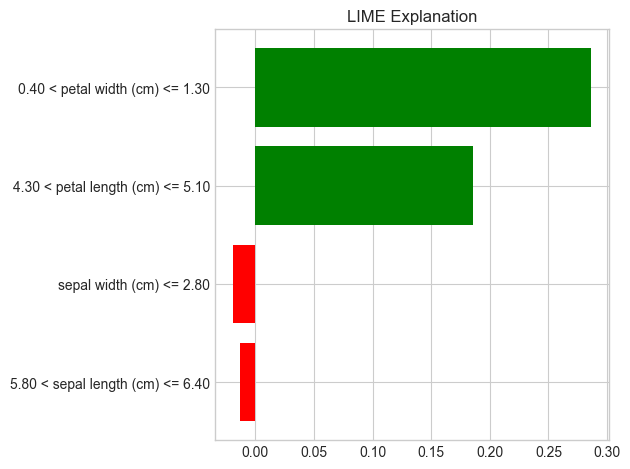

In [7]:
# Create the LIME explainer — it needs the training data to compute
# feature statistics (mean, std) for generating realistic perturbations
lime_explainer = LimeTabularExplainer(
    training_data=X_train,
    feature_names=feature_names,
    class_names=class_names,
    mode='classification'
)

# Wrapper function: LIME needs a function that returns class probabilities
def predict_proba_rf(data):
    return rf.predict_proba(data)

# Generate the LIME explanation for our selected instance
lime_exp = lime_explainer.explain_instance(
    sample.flatten(),
    predict_proba_rf,
    num_features=len(feature_names)
)

# Print the explanation as a list of (feature_condition, weight)
top_label = rf.predict(sample.reshape(1, -1))[0]
print(f"=== LIME Explanation (top label = {class_names[top_label]}) ===")
for fname, weight in lime_exp.as_list():
    sign = "+" if weight > 0 else ""
    print(f"  {sign}{weight:.4f}  {fname}")

# Visualise as a horizontal bar chart
lime_exp.as_pyplot_figure()
plt.title("LIME Explanation")
plt.tight_layout()
plt.show()

## 4. post-hoc explanations with SHAP

Predicted class: versicolor

=== SHAP Values (for predicted class: versicolor) ===
  +0.0215  sepal length (cm)
  +0.0030  sepal width (cm)
  +0.2838  petal length (cm)
  +0.3124  petal width (cm)


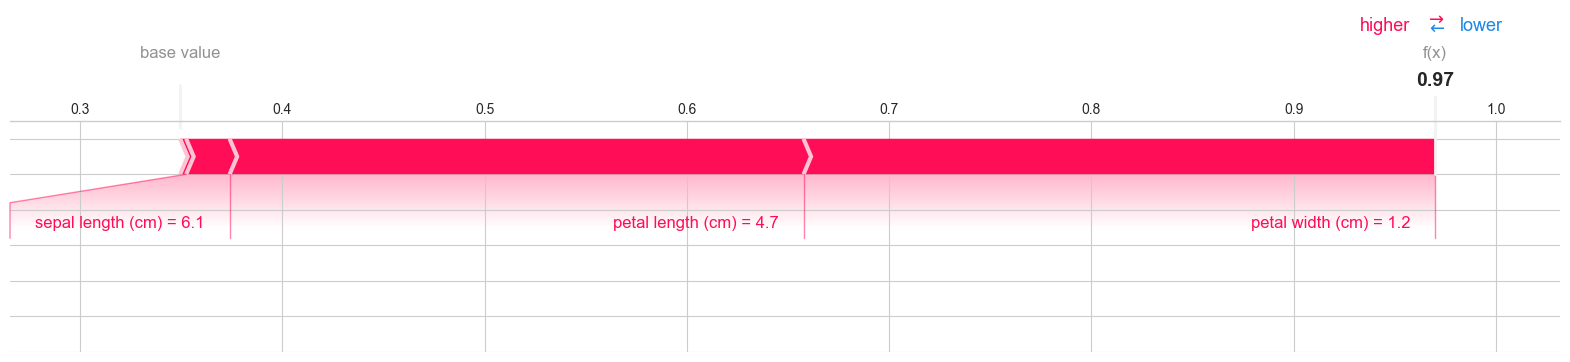

In [8]:
# Create a SHAP TreeExplainer (optimised for tree-based models like RF)
explainer_shap = shap.TreeExplainer(rf)

# Compute SHAP values for the single instance
# Returns a list of arrays: one (1, n_features) array per class
shap_values_single = explainer_shap.shap_values(sample.reshape(1, -1))

# Get the predicted class and extract its SHAP values
predicted_class = rf.predict(sample.reshape(1, -1))[0]
sv = shap_values_single[0][:, predicted_class]

print(f"Predicted class: {class_names[predicted_class]}")
print(f"\n=== SHAP Values (for predicted class: {class_names[predicted_class]}) ===")
for fname, sv_val in zip(feature_names, sv):
    sign = "+" if sv_val > 0 else ""
    print(f"  {sign}{sv_val:.4f}  {fname}")

# Force plot: visualises how each feature pushes the prediction
# away from the expected value (base value) toward the actual output
shap.force_plot(
    explainer_shap.expected_value[predicted_class],
    sv,
    sample,
    feature_names=feature_names,
    matplotlib=True
)
plt.show()

[('0.40 < petal width (cm) <= 1.30', 0.2865942505642204), ('4.30 < petal length (cm) <= 5.10', 0.1856191220303446), ('sepal width (cm) <= 2.80', -0.01920745375704196), ('5.80 < sepal length (cm) <= 6.40', -0.013298110119211668)]
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[('0.40 < petal width (cm) <= 1.30', 0.2865942505642204), ('4.30 < petal length (cm) <= 5.10', 0.1856191220303446), ('sepal width (cm) <= 2.80', -0.01920745375704196), ('5.80 < sepal length (cm) <= 6.40', -0.013298110119211668)]
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


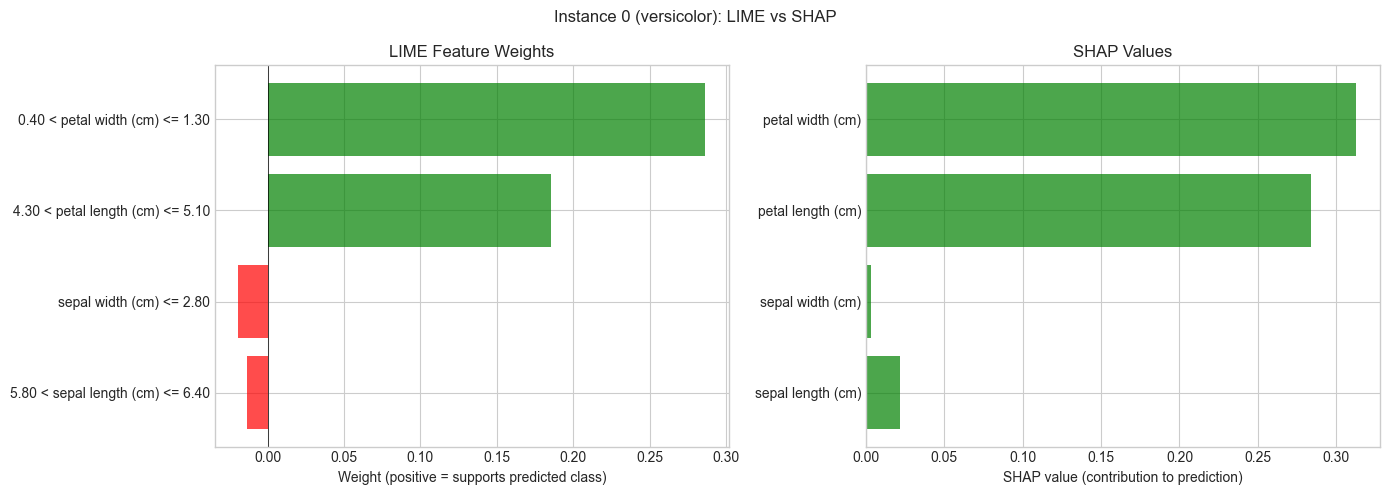


DT rule path (shallow tree):
  Node 0: petal length (cm) > 2.450  (sample value = 4.70)
  Node 2: petal length (cm) <= 4.750  (sample value = 4.70)
  Node 3: petal width (cm) <= 1.600  (sample value = 1.20)
  Leaf Node 4: predicted class = versicolor


In [9]:
# Collect LIME and SHAP explanations into dictionaries keyed by feature name
lime_dict = dict(lime_exp.as_list())
shap_dict = dict(zip(feature_names, sv))
lime_items = lime_exp.as_list()
lime_labels = [x[0] for x in lime_items]
lime_vals = [x[1] for x in lime_items]

# Plot LIME and SHAP side by side as horizontal bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

print(lime_exp.as_list())
print(feature_names)
# LIME bars
ax = axes[0]
colors_lime = ["green" if v > 0 else "red" for v in lime_vals]
ax.barh(lime_labels, lime_vals, color=colors_lime, alpha=0.7)
ax.set_title("LIME Feature Weights")
ax.set_xlabel("Weight (positive = supports predicted class)")
ax.axvline(0, color="black", linewidth=0.5)
ax.invert_yaxis()
print(lime_exp.as_list())
print(feature_names)

# SHAP 
ax = axes[1]
shap_vals = [shap_dict.get(fn, 0) for fn in feature_names]
colors_shap = ['green' if v > 0 else 'red' for v in shap_vals]
ax.barh(feature_names, shap_vals, color=colors_shap, alpha=0.7)
ax.set_title("SHAP Values")
ax.set_xlabel("SHAP value (contribution to prediction)")
ax.axvline(0, color='black', linewidth=0.5)

plt.suptitle(f"Instance {sample_idx} ({class_names[y_test[sample_idx]]}): LIME vs SHAP")
plt.tight_layout()
plt.show()

# Also print the DT rule path for comparison
print("\nDT rule path (shallow tree):")
print_dt_rule_path(dt_shallow, sample, feature_names, class_names)

## 5. SHAP Summary Plot (Global View)

The SHAP summary plot shows both feature importance and the **direction** of effects — whether high or low feature values push the prediction toward a specific class.

Generating SHAP summary plot for class: versicolor


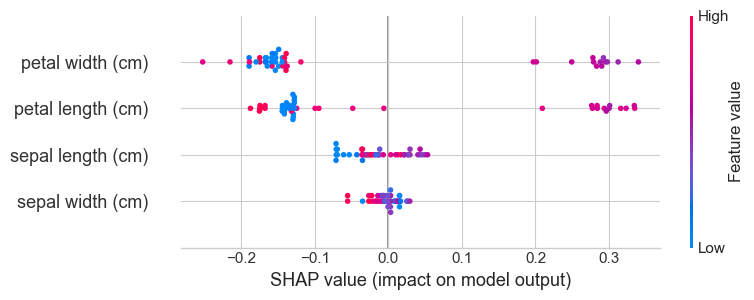

In [10]:

# The SHAP summary plot gives a global view of model behaviour.
#
# It shows:
# 1. Feature importance:
#    - Features higher on the plot have larger overall SHAP impact.
#
# 2. Direction of effect:
#    - Points to the right push the prediction toward the selected class.
#    - Points to the left push the prediction away from the selected class.
#
# 3. Feature value:
#    - Colour shows the actual feature value.
#    - Red usually means high feature value.
#    - Blue usually means low feature value.


# Choose which class to explain.
# For a multi-class model, SHAP gives separate explanations per class.
class_idx = 1  # change this if you want another class

print(f"Generating SHAP summary plot for class: {class_names[class_idx]}")

# Create a SHAP explainer for the trained Random Forest model.
explainer = shap.TreeExplainer(rf)

# Calculate SHAP values for the test set.
shap_values = explainer.shap_values(X_test)

# For classification models, shap_values is often a list:
# one array per class.
#
# Example:
# shap_values[0] = SHAP values for class 0
# shap_values[1] = SHAP values for class 1
# shap_values[2] = SHAP values for class 2
if isinstance(shap_values, list):
    sv_class = shap_values[class_idx]
else:
    # For some SHAP versions, the output may be a 3D array:
    # shape = (n_samples, n_features, n_classes)
    if len(shap_values.shape) == 3:
        sv_class = shap_values[:, :, class_idx]
    else:
        sv_class = shap_values

# Draw the SHAP summary plot.
# Each dot is one test instance.
# The x-axis shows how much that feature contributed to the prediction.
shap.summary_plot(
    sv_class,
    X_test,
    feature_names=feature_names,
    class_names=class_names,
    show=True
)




## 6. Global explanations 

In [11]:


# --- 1) SHAP global importance: compute SHAP values for ALL test instances ---
shap_values_test = explainer_shap.shap_values(X_test)

# Print mean |SHAP| per feature, for each class separately
for class_idx, class_name in enumerate(class_names):
    mean_abs_shap = np.abs(shap_values_test[class_idx]).mean(axis=0)
    print(f"\n=== SHAP Global Importance: {class_name} ===")
    for fn, imp in sorted(zip(feature_names, mean_abs_shap), key=lambda x: -x[1]):
        print(f"  {imp:.4f}  {fn}")

# --- 2) LIME aggregate: explain many instances and average the weights ---

# Dictionary to collect LIME weights for each original feature.
# Each key is a feature name, and each value is a list of weights from many samples.
lime_agg = defaultdict(list)

# Use at most 50 test samples for the aggregate LIME calculation.
# This keeps the computation reasonably fast.
sample_size = min(50, len(X_test))

# Choose a reproducible random subset of test indices.
indices = np.random.RandomState(42).choice(
    len(X_test),
    sample_size,
    replace=False
)

for idx in indices:
    # Explain one test instance using LIME.
    # X_test[idx].flatten() ensures the instance is a 1D array.
    # predict_proba_rf should return class probabilities from the random forest.
    exp = lime_explainer.explain_instance(
        X_test[idx].flatten(),
        predict_proba_rf,
        num_features=len(feature_names),
        top_labels=1
    )

    # Get the label/class that LIME chose as the top predicted class.
    label = exp.top_labels[0]

    # exp.as_list(...) returns pairs like:
    # ("petal length (cm) > 2.45", 0.31)
    #
    # These are condition strings, not exact feature names.
    # So we need to map each condition back to its original feature name.
    for condition, w in exp.as_list(label=label):

        # Check which original feature name appears inside the LIME condition string.
        for feature in feature_names:
            if feature in condition:
                # Store the LIME weight under the original feature name.
                lime_agg[feature].append(w)
                break

print("\n=== LIME Aggregate (mean |weight| per feature) ===")

for feature in feature_names:
    # Get all collected LIME weights for this feature.
    vals = lime_agg[feature]

    # If LIME never used this feature in any explanation, avoid np.mean([])
    # because that would produce nan.
    if len(vals) == 0:
        mean_w = 0.0
    else:
        # Use mean absolute weight so positive and negative effects do not cancel out.
        mean_w = np.mean(np.abs(vals))

    print(f"  {mean_w:.4f}  {feature}")




=== SHAP Global Importance: setosa ===
  0.1551  sepal width (cm)
  0.0882  petal length (cm)
  0.0740  sepal length (cm)

=== SHAP Global Importance: versicolor ===
  0.1812  sepal length (cm)
  0.1021  sepal width (cm)
  0.0886  petal length (cm)

=== SHAP Global Importance: virginica ===
  0.1573  petal length (cm)
  0.0866  sepal width (cm)
  0.0740  sepal length (cm)



=== LIME Aggregate (mean |weight| per feature) ===
  0.0238  sepal length (cm)
  0.0212  sepal width (cm)
  0.3278  petal length (cm)
  0.3468  petal width (cm)


---

## 7. Exercises

Work through the following questions using what you have learned in this practical.

---

### 7.1. Understanding Feature Importance

1. Which feature has the highest Gini importance in the shallow Decision Tree? Is this consistent with what LIME and SHAP tell you?

2. Re-run the notebook using `max_depth=2` for the shallow tree. Does the feature importance change? Why?

---

### 7.2. Boundary Cases

1. Find an instance in the test set where LIME and SHAP disagree on the most important feature. What could cause this disagreement?

2. Choose a sample near the decision boundary between *versicolor* and *virginica* (try `petal_length` around 4.5-5.0). How do the three explanations compare?

---

### 7.3. Model Comparison

1. Replace the Random Forest with a Decision Tree in the LIME and SHAP cells. Do the explanations change? Should they?

2. Train a shallow tree (`max_depth=3`) and a full tree on the same data. Use SHAP to explain the same instance with both trees. How do the SHAP values differ?

---

### 7.4. Global vs Local Explanations

1. Pick one instance from the test set and check whether its local LIME/SHAP explanation aligns with the global importance ranking. When would you expect them to disagree?

---

### 7.5. Interpretability vs Accuracy

1. How much accuracy do we lose by constraining the tree to `depth=3` vs `depth=None`?

2. Given the trade-off between interpretability (shallow tree) and accuracy (deep tree), which would you choose for a medical diagnosis application? Justify your answer.

7.1.
1. A feature com maior Gini é petal length, é o primeiro nó da árvore. LIME e SHAP confirmam isso, atribuindo-lhe também o maior peso.
2. Com max_depth=2, petal width pode desaparecer dos nós e a importância concentra-se ainda mais em petal length. Com menos nós, o modelo só usa o que é mesmo informativo.

7.2. 
1. LIME perturba a instância localmente e ajusta um modelo linear; SHAP usa teoria dos jogos sobre todas as combinações de features. Em zonas de fronteira, as perturbações do LIME podem cruzar a fronteira de decisão e distorcer os pesos, daí o desacordo.
2. Com petal_length entre 4.5–5.0, as explicações divergem mais. A DT dá uma regra binária mas a instância pode estar no limiar. O LIME fica instável. O SHAP mostra valores baixos ou com sinais contraditórios, reflectindo a incerteza do modelo.

7.3.
1. Mudam, e era esperado, o modelo mudou. A RF tem fronteiras mais suaves que uma DT, e LIME/SHAP capturam isso.
2. A árvore rasa concentra os SHAP values nas poucas features que usa; a profunda distribui por mais. Explicações mais simples, mas menos fiéis em zonas complexas.

7.4.
A importância global é uma média, reflecte o comportamento típico. Uma instância numa zona atípica pode ter uma explicação local completamente diferente. O desacordo é esperado quando a instância não é representativa do conjunto.

7.5. Interpretability vs Accuracy
1. No Iris a diferença é pequena, tipicamente 2–5 pp. O que a árvore profunda ganha deve-se sobretudo a overfitting.
2. Para diagnóstico médico, escolhia a árvore rasa. Explicabilidade numa aplicação clínica não é opcional, é um requisito ético e legal. Uma perda de 2–5% de accuracy é um preço razoável por rastreabilidade total das decisões.